#Data Loading and Processing

In [ ]:
!pip install datasets

In [ ]:
#loading datasets

from datasets import load_dataset

data_bundle = load_dataset("squad")

train_data = data_bundle["train"]

print("Total samples:", len(train_data))
print(train_data[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

Total samples: 87599
{'id': '5733be284776f41900661182', 'title': 'University_of_Notre_Dame', 'context': 'Architecturally, the school has a Catholic character. Atop the Main Building\'s gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin Mary reputedly appeared to Saint Bernadette Soubirous in 1858. At the end of the main drive (and in a direct line that connects through 3 statues and the Gold Dome), is a simple, modern stone statue of Mary.', 'question': 'To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?', 'answers': {'text': ['Saint Bernadette Soubirous'], 'answer_start': [515]}}


In [ ]:
print(train_data[0])

{'id': '5733be284776f41900661182', 'title': 'University_of_Notre_Dame', 'context': 'Architecturally, the school has a Catholic character. Atop the Main Building\'s gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin Mary reputedly appeared to Saint Bernadette Soubirous in 1858. At the end of the main drive (and in a direct line that connects through 3 statues and the Gold Dome), is a simple, modern stone statue of Mary.', 'question': 'To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?', 'answers': {'text': ['Saint Bernadette Soubirous'], 'answer_start': [515]}}


In [ ]:
#Processing data
processed_data = []

for row in train_data:
    if len(row["answers"]["text"]) > 0:
        processed_data.append({
            "question": row["question"],
            "context": row["context"],
            "answer": row["answers"]["text"][0]
        })

print(processed_data[0])
print("Total:", len(processed_data))

{'question': 'To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?', 'context': 'Architecturally, the school has a Catholic character. Atop the Main Building\'s gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin Mary reputedly appeared to Saint Bernadette Soubirous in 1858. At the end of the main drive (and in a direct line that connects through 3 statues and the Gold Dome), is a simple, modern stone statue of Mary.', 'answer': 'Saint Bernadette Soubirous'}
Total: 87599


In [ ]:
import random
sampled_data = random.sample(processed_data, 1500)
print(len(sampled_data))

1500


#RAG Agent Setup

In [ ]:
!pip install sentence-transformers faiss-cpu transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 60.6 MB/s eta 0:00:00


In [ ]:
#Removes duplicate documents

documents = list(set([row["context"] for row in sampled_data]))

print("Total documents:", len(documents))



Total documents: 1437


In [ ]:
# sentence transformer model it converts text to embeddings
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer('all-mpnet-base-v2')

doc_embeddings = embed_model.encode(documents, show_progress_bar=True)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/45 [00:00<?, ?it/s]

In [ ]:
#Faiss
import faiss
import numpy as np

dimension = doc_embeddings.shape[1]

faiss_index = faiss.IndexFlatL2(dimension)
faiss_index.add(np.array(doc_embeddings))

print("FAISS index ready")

FAISS index ready


In [ ]:
#Reranking
def rerank_docs(query, docs):

    query_emb = embed_model.encode([query])[0]

    scored = []

    for doc in docs:
        doc_emb = embed_model.encode([doc])[0]
        score = query_emb @ doc_emb
        scored.append((doc, score))

    scored.sort(key=lambda x: x[1], reverse=True)

    return [d[0] for d in scored]

In [ ]:
#retrieving documents
def retrieve_docs(user_query, top_k=3):
    query_embedding = embed_model.encode([user_query])

    distances, indices = faiss_index.search(np.array(query_embedding), top_k)

    results = [documents[i] for i in indices[0]]

    return results

#Benchmarking

##Comparing
●**Same agent across:**

    Different prompts

    Different retrieval strategies

    Different models*

In [ ]:
# Defining Prompts
def get_prompt(prompt_type, context, query):

    if prompt_type == "prompt1":
        return f"""
        You are a question answering system.

        Your task is to extract the EXACT answer from the given context.

        Rules:
        - Answer must be a SHORT PHRASE
        - Answer must be copied from the context
        - Do NOT explain
        - Do NOT guess

        Context: {context}
        Question: {query}

        Answer:
        """

    elif prompt_type == "prompt2":
        return f"""
        Read the context carefully and find the exact answer.

        Rules:
        - Return ONLY the exact answer from the context
        - If answer is not clearly present, return "Not found"
        - Do NOT include extra words
        - Do NOT guess

        Context: {context}
        Question: {query}

        Answer:
        """

In [ ]:
# Defining Retrieval Strategies
def get_context(query, strategy):

    if strategy == "top3":
        docs = retrieve_docs(query, top_k=3)

    elif strategy == "top5":
        docs = retrieve_docs(query, top_k=5)

    return " ".join(docs)

In [ ]:
#Defining Models

from transformers import pipeline

#Model_1
model_small = pipeline("text-generation", model="distilgpt2")
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

#model_2
tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-large")
model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-large")


def clean_answer(text):
    return text.split("\n")[0].strip()

def generate_large_model(prompt):

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)

    outputs = model.generate(
              **inputs,
              max_new_tokens=20,
              num_beams=5,
              early_stopping=True)
    answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return clean_answer(answer)


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

##Combined generator defination

In [ ]:
# Generation code
def generate_answer_config(query, prompt_type, retrieval_type, model_type):

    if retrieval_type == "top3":
        docs = retrieve_docs(query, top_k=3)

    elif retrieval_type == "top5":
        docs = retrieve_docs(query, top_k=5)


    docs = rerank_docs(query, docs)

    # Keeping same number after reranking
    if retrieval_type == "top3":
        docs = docs[:3]
    else:
        docs = docs[:5]

    context = " ".join(docs)

    prompt = get_prompt(prompt_type, context, query)

    if model_type == "small":
        response = model_small(prompt, max_length=200)
        return response[0]["generated_text"]

    elif model_type == "large":
        return generate_large_model(prompt)

##Metrics definations

In [ ]:
# Exact Match
def exact_match(predicted, actual):
    return int(predicted.strip().lower() == actual.strip().lower())

In [ ]:
#F1
def compute_f1(predicted, actual):
    pred_tokens = predicted.lower().split()
    actual_tokens = actual.lower().split()

    common = set(pred_tokens) & set(actual_tokens)

    if len(common) == 0:
        return 0

    precision = len(common) / len(pred_tokens)
    recall = len(common) / len(actual_tokens)

    return 2 * (precision * recall) / (precision + recall)

In [ ]:
#Retrieval Accuracy
def retrieval_accuracy(answer, retrieved_docs):
    context = " ".join(retrieved_docs)
    return int(answer.lower() in context.lower())

In [ ]:
#Faithfullness
import re

def compute_faithfulness(predicted_answer, retrieved_context):

    pred_words = set(re.findall(r'\w+', predicted_answer.lower()))
    context_words = set(re.findall(r'\w+', retrieved_context.lower()))

    if len(pred_words) == 0:
        return 0

    overlap = pred_words.intersection(context_words)

    return len(overlap) / len(pred_words)

In [ ]:
#Latency
import time

def measure_latency(query, generate_fn):
    start = time.time()
    answer = generate_fn(query)
    end = time.time()

    return answer, (end - start)

In [ ]:
#LLM as Judge

def llm_judge(question, ground_truth, predicted_answer):

    prompt = f"""
    Compare the predicted answer with ground truth.

    Question: {question}
    Ground Truth: {ground_truth}
    Predicted Answer: {predicted_answer}

    Is the predicted answer correct?

    Answer ONLY: Yes or No
    """

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True)

    outputs = model.generate(**inputs, max_new_tokens=10)

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    return response.strip()

In [ ]:
def parse_judge_output(text):

    text = text.lower()

    if "yes" in text:
        return {
            "correctness": 1,
            "completeness": 1,
            "reasoning": 1
        }
    else:
        return {
            "correctness": 0,
            "completeness": 0,
            "reasoning": 0
        }

##Training loop

In [ ]:
#training code

configs = [
    ("prompt1", "top3", "small"),
    ("prompt1", "top3", "large"),
    ("prompt1", "top5", "small"),
    ("prompt1", "top5", "large"),
    ("prompt2", "top3", "small"),
    ("prompt2", "top3", "large"),
    ("prompt2", "top5", "small"),
    ("prompt2", "top5", "large")
]

all_results = {}

for config in configs:

    prompt_type, retrieval_type, model_type = config

    key = f"{prompt_type}_{retrieval_type}_{model_type}"

    results = []

    for i in range(30):
        sample = sampled_data[i]

        query = sample["question"]
        gt = sample["answer"]

        pred, latency = measure_latency(
            query,
            lambda q: generate_answer_config(q, prompt_type, retrieval_type, model_type)
        )

        retrieved_docs = retrieve_docs(query)
        context = " ".join(retrieved_docs)

        em = exact_match(pred, gt)
        f1 = compute_f1(pred, gt)
        ret = retrieval_accuracy(gt, retrieved_docs)
        faith = compute_faithfulness(pred, context)
        judge_output = llm_judge(query, gt, pred)
        judge_scores = parse_judge_output(judge_output)

        results.append({
            "em": em,
            "f1": f1,
            "ret": ret,
            "faith": faith,
            "latency": latency,
            "correctness": judge_scores["correctness"],
    "completeness": judge_scores["completeness"],
    "reasoning": judge_scores["reasoning"]
        })


    summary = {
        "EM": sum(r["em"] for r in results)/len(results),
        "F1": sum(r["f1"] for r in results)/len(results),
        "Retrieval": sum(r["ret"] for r in results)/len(results),
        "Faithfulness": sum(r["faith"] for r in results)/len(results),
        "Latency": sum(r["latency"] for r in results)/len(results),

    "Correctness": sum(r["correctness"] for r in results)/len(results),
    "Completeness": sum(r["completeness"] for r in results)/len(results),
    "Reasoning": sum(r["reasoning"] for r in results)/len(results)
    }

    all_results[key] = summary

print(all_results)


Passing `generation_config` together with generation-related arguments=({'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_l

{'prompt1_top3_small': {'EM': 0.0, 'F1': 0.008231870030805532, 'Retrieval': 0.9666666666666667, 'Faithfulness': 0.8409954708395003, 'Latency': 2.1333117564519246, 'Correctness': 0.0, 'Completeness': 0.0, 'Reasoning': 0.0}, 'prompt1_top3_large': {'EM': 0.16666666666666666, 'F1': 0.26746031746031745, 'Retrieval': 0.9666666666666667, 'Faithfulness': 0.9666666666666667, 'Latency': 9.364819280306499, 'Correctness': 0.16666666666666666, 'Completeness': 0.16666666666666666, 'Reasoning': 0.16666666666666666}, 'prompt1_top5_small': {'EM': 0.0, 'F1': 0.00576719109587522, 'Retrieval': 0.9666666666666667, 'Faithfulness': 0.5664306670649343, 'Latency': 1.772273325920105, 'Correctness': 0.0, 'Completeness': 0.0, 'Reasoning': 0.0}, 'prompt1_top5_large': {'EM': 0.0, 'F1': 0.02828282828282828, 'Retrieval': 0.9666666666666667, 'Faithfulness': 0.75, 'Latency': 9.959580930074056, 'Correctness': 0.0, 'Completeness': 0.0, 'Reasoning': 0.0}, 'prompt2_top3_small': {'EM': 0.0, 'F1': 0.00823651142538261, 'Retri

##Results

In [ ]:
#results
for k, v in all_results.items():
    print("\nConfig:", k)
    print(v)


Config: prompt1_top3_small
{'EM': 0.0, 'F1': 0.008231870030805532, 'Retrieval': 0.9666666666666667, 'Faithfulness': 0.8409954708395003, 'Latency': 2.1333117564519246, 'Correctness': 0.0, 'Completeness': 0.0, 'Reasoning': 0.0}

Config: prompt1_top3_large
{'EM': 0.16666666666666666, 'F1': 0.26746031746031745, 'Retrieval': 0.9666666666666667, 'Faithfulness': 0.9666666666666667, 'Latency': 9.364819280306499, 'Correctness': 0.16666666666666666, 'Completeness': 0.16666666666666666, 'Reasoning': 0.16666666666666666}

Config: prompt1_top5_small
{'EM': 0.0, 'F1': 0.00576719109587522, 'Retrieval': 0.9666666666666667, 'Faithfulness': 0.5664306670649343, 'Latency': 1.772273325920105, 'Correctness': 0.0, 'Completeness': 0.0, 'Reasoning': 0.0}

Config: prompt1_top5_large
{'EM': 0.0, 'F1': 0.02828282828282828, 'Retrieval': 0.9666666666666667, 'Faithfulness': 0.75, 'Latency': 9.959580930074056, 'Correctness': 0.0, 'Completeness': 0.0, 'Reasoning': 0.0}

Config: prompt2_top3_small
{'EM': 0.0, 'F1': 0.

##Visualizations

In [ ]:
configs = [
    "p1_t3_small","p1_t3_large","p1_t5_small","p1_t5_large",
    "p2_t3_small","p2_t3_large","p2_t5_small","p2_t5_large"
]

F1 = [
    0.00823, 0.26746, 0.00576, 0.02828,
    0.00823, 0.19666, 0.00570, 0.0
]

EM = [
    0.0, 0.1667, 0.0, 0.0,
    0.0, 0.1333, 0.0, 0.0
]

Faith = [
    0.84099, 0.96666, 0.56643, 0.75,
    0.83018, 0.46666, 0.56379, 0.3
]

Latency = [
    2.13, 9.36, 1.77, 9.95,
    1.77, 8.33, 1.80, 8.71
]

# LLM Judge Metrics
Correctness = [
    0.0, 0.1667, 0.0, 0.0,
    0.0, 0.1667, 0.0, 0.0
]

Completeness = [
    0.0, 0.1667, 0.0, 0.0,
    0.0, 0.1667, 0.0, 0.0
]

Reasoning = [
    0.0, 0.1667, 0.0, 0.0,
    0.0, 0.1667, 0.0, 0.0
]

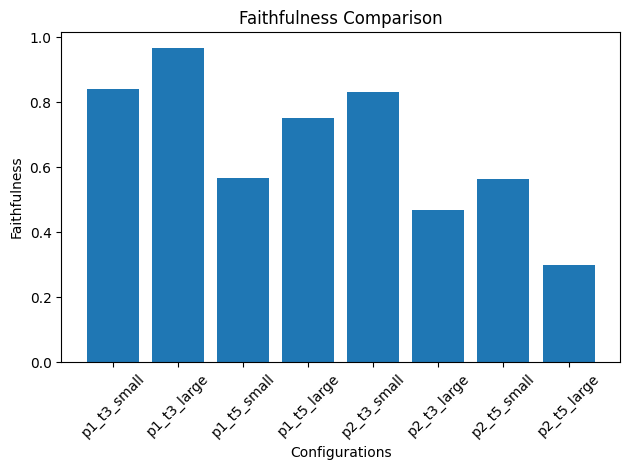

In [ ]:
#Faithfulness Comparison plot
plt.figure()
plt.bar(configs, Faith)

plt.xticks(rotation=45)
plt.title("Faithfulness Comparison")
plt.xlabel("Configurations")
plt.ylabel("Faithfulness")

plt.tight_layout()
plt.show()

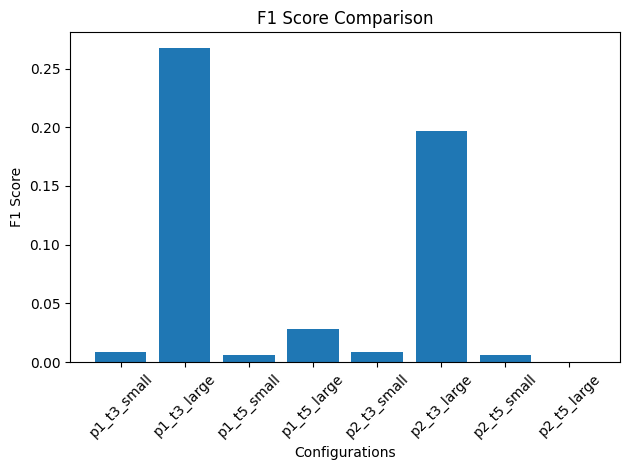

In [ ]:
#F1 Score plot
import matplotlib.pyplot as plt

plt.figure()
plt.bar(configs, F1)

plt.xticks(rotation=45)
plt.title("F1 Score Comparison")
plt.xlabel("Configurations")
plt.ylabel("F1 Score")

plt.tight_layout()
plt.show()

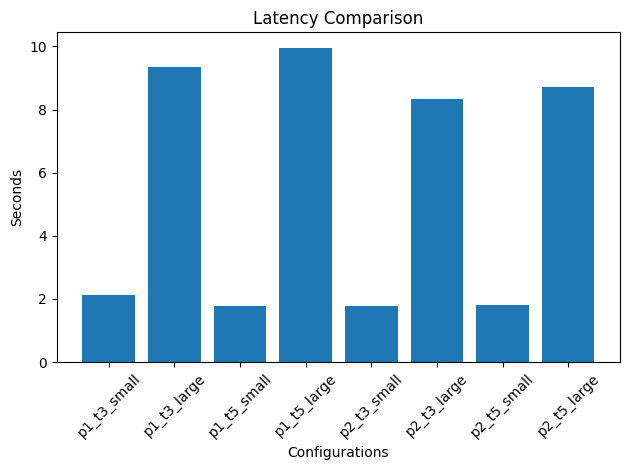

In [ ]:
#Latency Comparison plot
plt.figure()
plt.bar(configs, Latency)

plt.xticks(rotation=45)
plt.title("Latency Comparison")
plt.xlabel("Configurations")
plt.ylabel("Seconds")

plt.tight_layout()
plt.show()

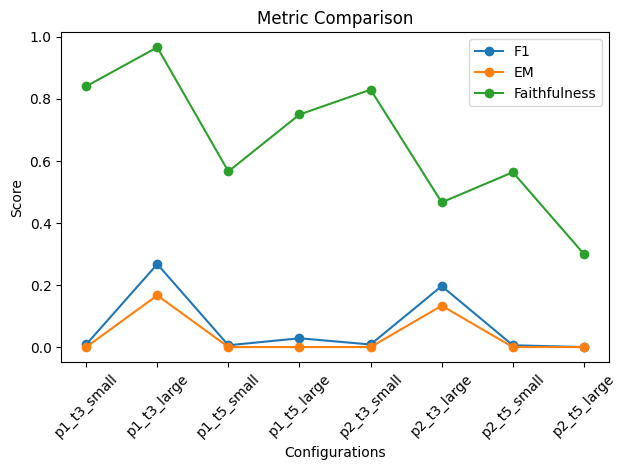

In [ ]:
#combined plot
plt.figure()

plt.plot(configs, F1, marker='o', label="F1")
plt.plot(configs, EM, marker='o', label="EM")
plt.plot(configs, Faith, marker='o', label="Faithfulness")

plt.xticks(rotation=45)
plt.title("Metric Comparison")
plt.xlabel("Configurations")
plt.ylabel("Score")

plt.legend()
plt.tight_layout()
plt.show()